# Comparaison S and tied

In [1]:
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt
import torch
import glob
import os

## Label error + ACC as a function of d_MLP (alpha fix)

In [2]:
run_id_S = "20251201_2051"
run_id_tied = "20251201_1537"

run_dir_S = f"../results/run_{run_id_S}/"
config_path_S = f"../results/run_{run_id_S}/config.csv"
base_path_S = f"../results/run_{run_id_S}/summary.csv"

run_dir_tied = f"../results/run_{run_id_tied}/"
config_path_tied = f"../results/run_{run_id_tied}/config.csv"
base_path_tied = f"../results/run_{run_id_tied}/summary.csv"

plot_path = f"../results/S_tied/"
os.makedirs(plot_path, exist_ok=True)

In [3]:
# --- Read the CSV file ---
df_S = pd.read_csv(base_path_S)
print(f"✅ Summary loaded ({len(df_S)} rows) from {base_path_S}")
display(df_S.head())

# --- Read the CSV file ---
df_tied = pd.read_csv(base_path_tied)
print(f"✅ Summary loaded ({len(df_tied)} rows) from {base_path_tied}")
display(df_tied.head())

plt.rcParams.update({'font.size': 12}) 

✅ Summary loaded (60 rows) from ../results/run_20251201_2051/summary.csv


,alpha,MLP_dim,rho,label_err_mean,label_err_std,train_data_mean,train_reg_mean,train_total_mean,train_total_std,acc_test_mean,acc_test_std,acc_fine_tune_mean,acc_fine_tune_std,acc_train_mean,acc_train_std,rank_before_mean,rank_before_std,rank_after_mean,rank_after_std
0,0.807143,5,1.0,0.000091,0.000004,0.000139,0.000016,0.000155,0.000024,0.088472,0.038334,0.146292,0.050567,0.480940,0.088287,99.30,1.031095,98.05,2.645254
1,0.807143,10,1.0,0.000091,0.000003,0.000101,0.000023,0.000123,0.000011,0.088889,0.025886,0.234550,0.051294,0.597160,0.056427,99.35,0.875094,99.60,0.502625
2,0.807143,30,1.0,0.000082,0.000004,0.000040,0.000030,0.000070,0.000008,0.179583,0.040986,0.354131,0.055964,0.851907,0.049187,99.60,0.502625,99.85,0.366348
3,0.807143,50,1.0,0.000082,0.000004,0.000024,0.000031,0.000055,0.000007,0.184167,0.035824,0.446964,0.073917,0.914332,0.043813,99.30,0.732695,99.80,0.410391
4,0.100000,5,1.0,0.000089,0.000008,0.000010,0.000018,0.000029,0.000027,0.109167,0.075408,0.604700,0.199878,0.967167,0.086955,99.05,0.825578,96.75,3.242400


✅ Summary loaded (60 rows) from ../results/run_20251201_1537/summary.csv


,alpha,MLP_dim,rho,label_err_mean,label_err_std,train_data_mean,train_reg_mean,train_total_mean,train_total_std,acc_test_mean,acc_test_std,acc_fine_tune_mean,acc_fine_tune_std,acc_train_mean,acc_train_std,rank_before_mean,rank_before_std,rank_after_mean,rank_after_std
0,0.100000,5,1.0,0.000096,0.000002,2.745174e-06,0.000013,0.000016,6.407575e-06,0.040000,0.024423,1.000000,0.000000,0.989829,0.018812,99.80,0.410391,99.50,0.888523
1,0.100000,10,1.0,0.000083,0.000002,1.147868e-06,0.000011,0.000013,2.792606e-06,0.170833,0.020142,1.000000,0.000000,0.998871,0.003916,99.55,0.759155,99.70,0.571241
2,0.100000,30,1.0,0.000088,0.000008,7.968677e-07,0.000011,0.000012,1.260433e-06,0.122500,0.082412,0.955733,0.074443,1.000000,0.000000,99.65,0.489360,99.20,0.523148
3,0.100000,50,1.0,0.000097,0.000003,5.808530e-07,0.000008,0.000009,3.813734e-07,0.030833,0.034317,0.035413,0.065155,1.000000,0.000000,99.10,0.552506,98.60,1.142481
4,0.807143,5,1.0,0.000069,0.000005,1.417255e-04,0.000019,0.000160,1.682212e-05,0.313889,0.045963,0.380205,0.045795,0.486110,0.072910,100.00,0.000000,99.65,0.489360


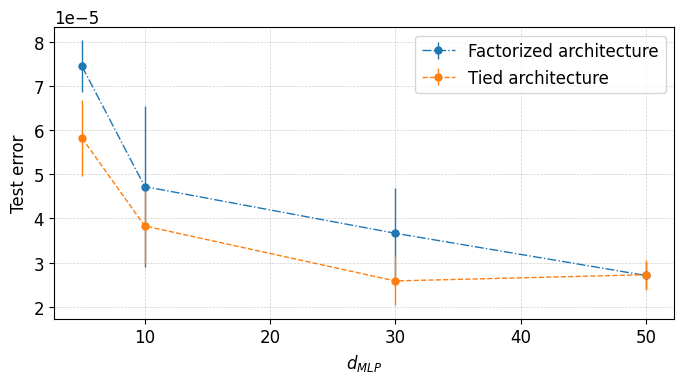

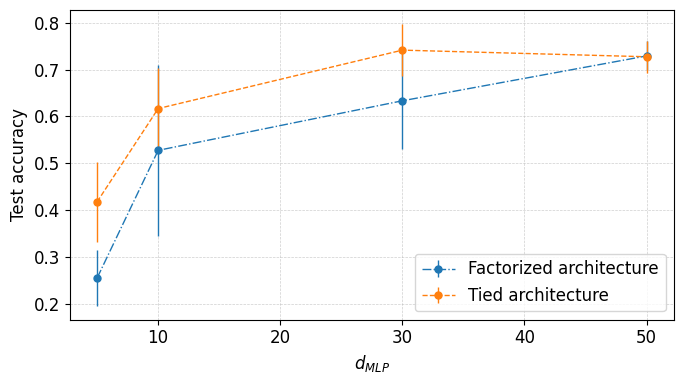

In [4]:
alpha_target = 10
subset_S = df_S[df_S["alpha"] == alpha_target].sort_values("MLP_dim")
subset_tied = df_tied[df_tied["alpha"] == alpha_target].sort_values("MLP_dim")

plt.figure(figsize=(7, 4))

plt.errorbar(
    subset_S["MLP_dim"],
    subset_S["label_err_mean"],
    yerr=subset_S.get("label_err_std", 0),
    marker='o',
    markersize=5,
    linewidth=1,
    capsize=0,
    label="Factorized architecture",    
    linestyle='-.'
)

plt.errorbar(
    subset_tied["MLP_dim"],
    subset_tied["label_err_mean"],
    yerr=subset_tied.get("label_err_std", 0),
    marker='o',
    markersize=5,
    linewidth=1,
    capsize=0,
    label="Tied architecture",
    linestyle='--'
)

plt.xlabel(r"$d_{MLP}$")
plt.ylabel("Test error")
# plt.title(fr"Test error vs MLP dim (α = {alpha_target})")
plt.legend()
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
plt.tight_layout()

plt.savefig(
    os.path.join(plot_path, f"label_error_vs_MLPdim_alpha{alpha_target}_run{run_id_S}.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

plt.figure(figsize=(7, 4))

plt.errorbar(
    subset_S["MLP_dim"],
    subset_S["acc_test_mean"],
    yerr=subset_S.get("acc_test_std", 0),
    marker='o',
    markersize=5,
    linewidth=1,
    capsize=0,
    label="Factorized architecture",
    linestyle='-.'
)

plt.errorbar(
    subset_tied["MLP_dim"],
    subset_tied["acc_test_mean"],
    yerr=subset_tied.get("acc_test_std", 0),
    marker='o',
    markersize=5,
    linewidth=1,
    capsize=0,
    label="Tied architecture",
    linestyle='--'
)

plt.xlabel(r"$d_{MLP}$")
plt.ylabel("Test accuracy")
# plt.title(fr"Test accuracy vs MLP dim (α = {alpha_target})")
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
plt.tight_layout()
plt.legend()

plt.savefig(
    os.path.join(plot_path, f"Test accuracyr_vs_MLPdim_alpha{alpha_target}_run{run_id_S}.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Label error + ACC vs. alpha (d_MLP fix)

In [5]:
run_id_S = "20251201_2051"
run_id_tied = "20251201_1537"

run_dir_S = f"../results/run_{run_id_S}/"
config_path_S = f"../results/run_{run_id_S}/config.csv"
base_path_S = f"../results/run_{run_id_S}/summary.csv"

run_dir_tied = f"../results/run_{run_id_tied}/"
config_path_tied = f"../results/run_{run_id_tied}/config.csv"
base_path_tied = f"../results/run_{run_id_tied}/summary.csv"

plot_path = f"../results/S_tied/"
os.makedirs(plot_path, exist_ok=True)

# --- Read the CSV file ---
df_S = pd.read_csv(base_path_S)
print(f"✅ Summary loaded ({len(df_S)} rows) from {base_path_S}")
display(df_S.head())

# --- Read the CSV file ---
df_tied = pd.read_csv(base_path_tied)
print(f"✅ Summary loaded ({len(df_tied)} rows) from {base_path_tied}")
display(df_tied.head())

plt.rcParams.update({'font.size': 12}) 

✅ Summary loaded (60 rows) from ../results/run_20251201_2051/summary.csv


,alpha,MLP_dim,rho,label_err_mean,label_err_std,train_data_mean,train_reg_mean,train_total_mean,train_total_std,acc_test_mean,acc_test_std,acc_fine_tune_mean,acc_fine_tune_std,acc_train_mean,acc_train_std,rank_before_mean,rank_before_std,rank_after_mean,rank_after_std
0,0.807143,5,1.0,0.000091,0.000004,0.000139,0.000016,0.000155,0.000024,0.088472,0.038334,0.146292,0.050567,0.480940,0.088287,99.30,1.031095,98.05,2.645254
1,0.807143,10,1.0,0.000091,0.000003,0.000101,0.000023,0.000123,0.000011,0.088889,0.025886,0.234550,0.051294,0.597160,0.056427,99.35,0.875094,99.60,0.502625
2,0.807143,30,1.0,0.000082,0.000004,0.000040,0.000030,0.000070,0.000008,0.179583,0.040986,0.354131,0.055964,0.851907,0.049187,99.60,0.502625,99.85,0.366348
3,0.807143,50,1.0,0.000082,0.000004,0.000024,0.000031,0.000055,0.000007,0.184167,0.035824,0.446964,0.073917,0.914332,0.043813,99.30,0.732695,99.80,0.410391
4,0.100000,5,1.0,0.000089,0.000008,0.000010,0.000018,0.000029,0.000027,0.109167,0.075408,0.604700,0.199878,0.967167,0.086955,99.05,0.825578,96.75,3.242400


✅ Summary loaded (60 rows) from ../results/run_20251201_1537/summary.csv


,alpha,MLP_dim,rho,label_err_mean,label_err_std,train_data_mean,train_reg_mean,train_total_mean,train_total_std,acc_test_mean,acc_test_std,acc_fine_tune_mean,acc_fine_tune_std,acc_train_mean,acc_train_std,rank_before_mean,rank_before_std,rank_after_mean,rank_after_std
0,0.100000,5,1.0,0.000096,0.000002,2.745174e-06,0.000013,0.000016,6.407575e-06,0.040000,0.024423,1.000000,0.000000,0.989829,0.018812,99.80,0.410391,99.50,0.888523
1,0.100000,10,1.0,0.000083,0.000002,1.147868e-06,0.000011,0.000013,2.792606e-06,0.170833,0.020142,1.000000,0.000000,0.998871,0.003916,99.55,0.759155,99.70,0.571241
2,0.100000,30,1.0,0.000088,0.000008,7.968677e-07,0.000011,0.000012,1.260433e-06,0.122500,0.082412,0.955733,0.074443,1.000000,0.000000,99.65,0.489360,99.20,0.523148
3,0.100000,50,1.0,0.000097,0.000003,5.808530e-07,0.000008,0.000009,3.813734e-07,0.030833,0.034317,0.035413,0.065155,1.000000,0.000000,99.10,0.552506,98.60,1.142481
4,0.807143,5,1.0,0.000069,0.000005,1.417255e-04,0.000019,0.000160,1.682212e-05,0.313889,0.045963,0.380205,0.045795,0.486110,0.072910,100.00,0.000000,99.65,0.489360


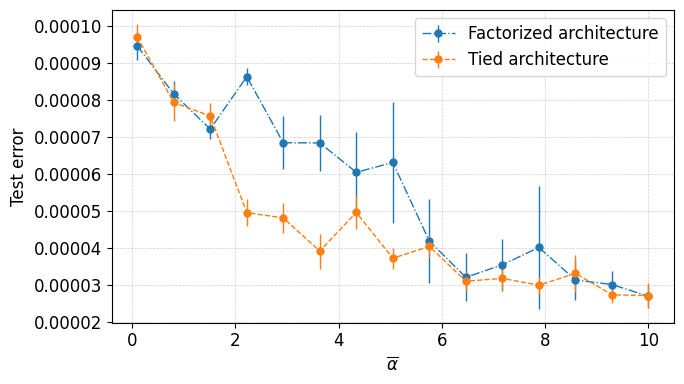

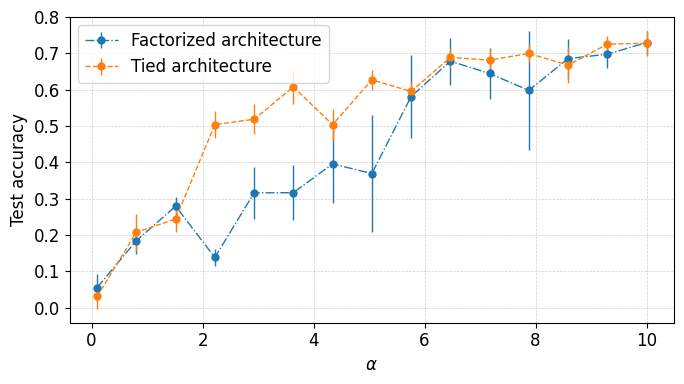

In [12]:
MLP_target = 50  # <-- choisis ton d_MLP

subset_S = df_S[df_S["MLP_dim"] == MLP_target].sort_values("alpha")
subset_tied = df_tied[df_tied["MLP_dim"] == MLP_target].sort_values("alpha")

# -------------------- LABEL ERROR --------------------
plt.figure(figsize=(7, 4))

plt.errorbar(
    subset_S["alpha"],
    subset_S["label_err_mean"],
    yerr=subset_S.get("label_err_std", 0),
    marker='o',
    markersize=5,
    linewidth=1,
    capsize=0,
    label="Factorized architecture",
    linestyle='-.'
)

plt.errorbar(
    subset_tied["alpha"],
    subset_tied["label_err_mean"],
    yerr=subset_tied.get("label_err_std", 0),
    marker='o',
    markersize=5,
    linewidth=1,
    capsize=0,
    label="Tied architecture",
    linestyle='--'
)

plt.xlabel(r"$\overline{\alpha}$")
plt.ylabel("Test error")
plt.legend()
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
plt.tight_layout()

plt.savefig(
    os.path.join(plot_path, f"label_error_vs_alpha_MLP{MLP_target}_run{run_id_S}.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()


# -------------------- TEST ACCURACY --------------------
plt.figure(figsize=(7, 4))

plt.errorbar(
    subset_S["alpha"],
    subset_S["acc_test_mean"],
    yerr=subset_S.get("acc_test_std", 0),
    marker='o',
    markersize=5,
    linewidth=1,
    capsize=0,
    label="Factorized architecture",
    linestyle='-.'
)

plt.errorbar(
    subset_tied["alpha"],
    subset_tied["acc_test_mean"],
    yerr=subset_tied.get("acc_test_std", 0),
    marker='o',
    markersize=5,
    linewidth=1,
    capsize=0,
    label="Tied architecture",
    linestyle='--'
)

plt.xlabel(r"$\overline{\alpha}$")
plt.ylabel("Test accuracy")
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
plt.tight_layout()
plt.legend()

plt.savefig(
    os.path.join(plot_path, f"test_accuracy_vs_alpha_MLP{MLP_target}_run{run_id_S}.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()